# 命令

- `ctrl+alt+⬅`:返回上一个光标位置
- `ctrl+Z`:撤销上一步操作

In [4]:
#!使用shell命令
# !conda list
!conda info --e 
!jupyter --version
#magic命令 %:行命令 %%:单元格命令
%lsmagic
#查看用法 ?:普通信息 ??:详细信息 
# ?print

# conda environments:
#
base                  *  D:\Download\Anaconda3

jupyter core     : 4.7.1
jupyter-notebook : 6.3.0
qtconsole        : 5.0.3
ipython          : 8.6.0
ipykernel        : 6.17.1
jupyter client   : 6.1.12
jupyter lab      : 3.0.14
nbconvert        : 6.0.7
ipywidgets       : 7.6.3
nbformat         : 5.1.3
traitlets        : 5.5.0


Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cd  %clear  %cls  %colors  %conda  %config  %connect_info  %copy  %ddir  %debug  %dhist  %dirs  %doctest_mode  %echo  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %macro  %magic  %matplotlib  %mkdir  %more  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %ren  %rep  %rerun  %reset  %reset_selective  %rmdir  %run  %save  %sc  %set_env  %store  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%cmd  %%debug  %%file  %%html  %%javascript  %%js  %%latex  %%markdown  %%perl  %%prun  %%pypy  %%python 

In [5]:
#查看计算机信息
import psutil
print(psutil.cpu_count(logical=False),psutil.cpu_count())
import torch
print(torch.__version__)#torch的版本
print(torch.cuda.is_available())#cuda是否可用
print(torch.cuda.device_count())# 返回gpu数量
print(torch.cuda.get_device_name(0))# 返回gpu名字，设备索引默认从0开始
print(torch.cuda.current_device())# 返回当前设备索引
print(torch.version.cuda) # 查看CUDA的版本号
print(torch.backends.cudnn.version())
# os.environ["CUDA_VISIBLE_DEVICES"] = "0, 1, 2, 3"#官方推荐的指定GPU的命令;切换GPU的索引
x = torch.ones(2,3)
print(x.device)
y = x.cuda(0)
print(y.device)

6 12
1.12.0+cu116
True
1
NVIDIA GeForce RTX 3050 Laptop GPU
0
11.6
8302
cpu
cuda:0


In [6]:
# import os
# # 切换当前工作路径
# os.chdir(path='/home/hfut3304/data/workspace_wzj/DKT/')
# # 表示当前所处的文件夹的绝对路径
# print(os.getcwd())
# print(os.path.abspath('.'))
# # 表示当前所处的文件夹上一级文件夹的绝对路径
# print(os.path.abspath('..'))
# print(os.path.abspath(os.path.join(os.getcwd(), "..")))
# # 获取上上级目录
# print(os.path.abspath(os.path.join(os.getcwd(), "../..")))

In [7]:
import sys
sys.getdefaultencoding()
### 1.python2中，如果代码或者注释有中文，在python文件的开头加入
# -*- coding: UTF-8 -*-
# coding=utf-8 推荐使用
# 注：如果是读写文件为 encoding: utf-8
### 2.设置Linux/Unix用户的解释器路径
#!/usr/bin/env python

'utf-8'

# 输入

In [8]:
import torch
from torch import nn
embed = torch.nn.Embedding(num_embeddings=10, embedding_dim=4)#[10,4]
# word2id的作用，1表示EOS，2表示PAD
batch = [[3, 6, 5, 6, 7, 1], [6, 4, 7, 9, 5, 1], [4, 5, 8, 7, 1, 2]]#[3,6]
batch = torch.LongTensor(batch)
batch = batch.reshape(6, 3)  # [seq_len,batch_size]排序>>为了在RNN模型中进行训练
batch_embed = embed(batch)  # [6,3,10][10,4]=[6,3,4]，不能超过10类
batch_embed.size()

torch.Size([6, 3, 4])

# 输出

In [9]:
### 过滤代码warnings输出
import warnings
# run block of code and catch warnings
with warnings.catch_warnings():
    # ignore all caught warnings
    warnings.filterwarnings("ignore") #可以不catch直接filter
    # execute code that will generate warnings
    ...

import torch
import torchvision

# resnet = torchvision.models.resnet50(pretrained=False)#无预训练参数
resnet = torchvision.models.resnet50(pretrained=True)
# print(resnet)#打印网络结构
# resnet.classifier.add_module("add_linear",nn.Linear(1000,10)) # 在resnet50的classfier里加一层
# resnet.classifier[6] = nn.Linear(4096,10) # 修改对应层,编号相对应
resnet=list(resnet.children())[:-2]#去掉后两层只保留（2048，7，7）
resnet = torch.nn.Sequential(*resnet)
input = torch.randn(2,3,224,224)
output = resnet(input)
output.size()

# ### 模型保存与加载
# # 保存方法 1 
# torch.save(vgg16,"vgg16_method1.pth") # 保存结构模型和参数
# # 加载模型 1
# model = torch.load("vgg16_method1.pth")

# # 保存方式 2 -- 以字典方式只保存参数（官方推荐),
# torch.save(vgg16.state_dict(),"vgg_method2.pth") 
# # 加载方式 2 -- 要恢复网络模型
# model = torch.load("vgg_method2.pth")
# vgg16 = torchvision.models.vgg16(pretrained = True)
# vgg16.load_state_dict(torch.load("vgg_method2.pth"))

d:\Download\Anaconda3\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
d:\Download\Anaconda3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([2, 2048, 7, 7])

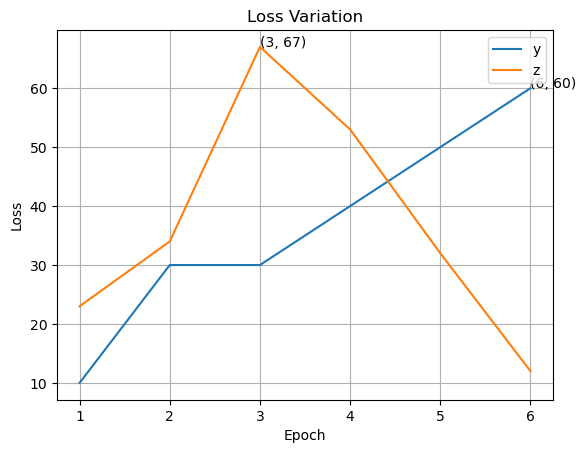

In [10]:
#绘制Loss曲线
from matplotlib import pyplot as plt
y = [10, 30, 30, 40, 50, 60]
z = [23, 34, 67, 53, 32, 12]
x = list(range(1,len(y)+1))
plt.plot(x, y, label="y")
plt.plot(x, z, label="z")
plt.legend()
b = max(y)
a1 = y.index(b)+1
c = max(z)
a2 = z.index(c)+1
plt.text(a1, b, (a1, b))
plt.text(a2, c, (a2, c))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Variation")
plt.grid()

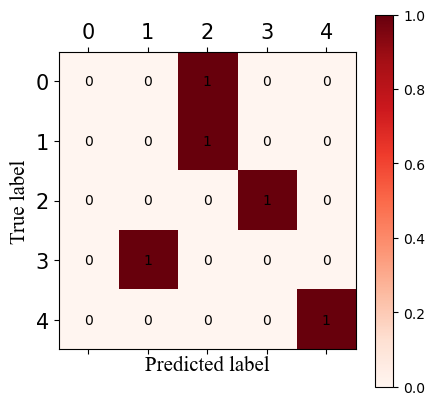

In [11]:
#绘制混淆矩阵
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
y_pred =  ['2','2','3','1','4']
y_true =  ['0','1','2','3','4'] 
C = confusion_matrix(y_true, y_pred, labels=['0','1','2','3','4']) # 可将'1'等替换成自己的类别，如'cat'。
plt.matshow(C, cmap=plt.cm.Reds) # 根据最下面的图按自己需求更改颜色
plt.colorbar()
for i in range(len(C)):
    for j in range(len(C)):
        plt.annotate(C[j, i], xy=(i, j), horizontalalignment='center', verticalalignment='center')
plt.tick_params(labelsize=15) # 设置左边和上面的label类别如0,1,2,3,4的字体大小。
plt.ylabel('True label', fontdict={'family': 'Times New Roman', 'size': 15})
plt.xlabel('Predicted label', fontdict={'family': 'Times New Roman', 'size': 15})
plt.show()